# 02 · Batch benchmark — tuned WiSARD vs tuned LR/RF + error analysis

With the encoding settled in **01**, we now ask the fairness question properly: across
**accuracy · memory · train/infer time**, where does a *well-tuned* WiSARD sit next to
*well-tuned* classical baselines? "Well-tuned" cuts both ways — LR and RF get a
comprehensive search over **their own** exclusive hyperparameters, so neither is a
strawman. Then we don't just rank the models — we **look at what each got right and
wrong**, and how each represents the problem internally.

In [1]:
import sys, os, json, importlib
sys.path.insert(0, '.')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import synthetic as S, characters as C, detector as D, bench
for _m in (S, C, D, bench): importlib.reload(_m)
import wisardpkg as wp
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, confusion_matrix
import warnings; warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110
CACHE_DIR = './cache'
CANON = 24

## The contenders
- **WiSARD** — the grid winner from notebook 01, on its fitted thermometer.
- **LR** and **RF** — on raw float pixels, each tuned below over its own hyperparameters.

In [2]:
best = json.load(open(f'{CACHE_DIR}/best_wisard.json')) if os.path.exists(f'{CACHE_DIR}/best_wisard.json') \
       else dict(kind='gaussian', size=8, addr=16)
print('WiSARD config from 01:', best)

def fit_wisard(Xtr_c, cfg):
    th = bench.fit_thermometer(Xtr_c, cfg['kind'], cfg['size'])
    return bench.WNNModel(f"WiSARD", (lambda n, a=cfg['addr']: wp.Wisard(a)),
                          encoder=(lambda Xc, t=th: bench.thermometer_encode(Xc, t)))

WiSARD config from 01: {'kind': 'gaussian', 'size': 13, 'addr': 12}


## Tuning the baselines (their exclusive hyperparameters)
A 3-seed-mean grid for each. RF over `n_estimators × max_depth × max_features`; LR over
`C × penalty`. We pick each model's best clean-preset config — fairness demands the
baselines be as tuned as the WiSARD.

In [3]:
def data(preset, n, seed):
    X, y = C.make_dataset(n, size=48, seed=seed, **C.PRESETS[preset]); return bench.to_canon(X, CANON), y
def feats(Xc): return bench.raw_float(Xc)

SEEDS = [1, 2, 3]
def cv_score(make):
    s = []
    for sd in SEEDS:
        Xtr, ytr = data('clean', 120, sd); Xte, yte = data('clean', 50, 100 + sd)
        clf = make().fit(feats(Xtr), ytr)
        s.append(f1_score(yte, clf.predict(feats(Xte)), average='macro'))
    return float(np.mean(s))

rf_grid = [dict(n_estimators=ne, max_depth=md, max_features=mf)
           for ne in [100, 300] for md in [10, 16, None] for mf in ['sqrt', 0.3]]
rf_res = [{**g, 'f1': round(cv_score(lambda g=g: RandomForestClassifier(n_jobs=-1, random_state=1, **g)), 3)} for g in rf_grid]
rf_best = max(rf_res, key=lambda r: r['f1'])
lr_grid = [dict(C=c, penalty=p, solver=('saga' if p == 'l1' else 'lbfgs'))
           for c in [0.05, 0.5, 5.0] for p in ['l2', 'l1']]
lr_res = [{**g, 'f1': round(cv_score(lambda g=g: LogisticRegression(max_iter=500, **g)), 3)} for g in lr_grid]
lr_best = max(lr_res, key=lambda r: r['f1'])
print('RF best:', rf_best); print('LR best:', lr_best)
pd.DataFrame(rf_res).sort_values('f1', ascending=False).head(4)

RF best: {'n_estimators': 300, 'max_depth': 16, 'max_features': 'sqrt', 'f1': 0.954}
LR best: {'C': 0.5, 'penalty': 'l2', 'solver': 'lbfgs', 'f1': 0.851}


,n_estimators,max_depth,max_features,f1
8,300,16.0,sqrt,0.954
10,300,NaN,sqrt,0.954
2,100,16.0,sqrt,0.950
4,100,NaN,sqrt,0.950


In [4]:
# Factories for the tuned baselines
def make_rf(): return RandomForestClassifier(n_jobs=-1, random_state=1,
              **{k: rf_best[k] for k in ['n_estimators', 'max_depth', 'max_features']})
def make_lr(): return LogisticRegression(max_iter=500, **{k: lr_best[k] for k in ['C', 'penalty', 'solver']})
pd.DataFrame(lr_res).sort_values('f1', ascending=False).head(4)

,C,penalty,solver,f1
2,0.50,l2,lbfgs,0.851
0,0.05,l2,lbfgs,0.850
4,5.00,l2,lbfgs,0.834
5,5.00,l1,saga,0.829


## Head-to-head: accuracy · memory · time
All three tuned models, on clean and full difficulty.

In [5]:
rows = []
for preset in ['clean', 'full']:
    Xtr, ytr = data(preset, 150, 1); Xte, yte = data(preset, 60, 2)
    models = [fit_wisard(Xtr, best),
              bench.SklearnModel('RF', make_rf()), bench.SklearnModel('LR', make_lr())]
    for mdl in models:
        r = bench.evaluate(mdl, Xtr, ytr, Xte, yte, canon=CANON)
        r['preset'] = preset; rows.append(r)
bench_df = pd.DataFrame(rows)
bench_df.pivot_table(index='model', columns='preset', values=['f1', 'mem_kb', 'infer_ms'])

f1        infer_ms          mem_kb         
preset  clean   full    clean   full    clean     full
model                                                 
LR      0.844  0.669    0.004  0.004     81.0     81.0
RF      0.949  0.771    0.073  0.070   4439.3   8136.0
WiSARD  0.904  0.721    1.090  1.194  10012.8  12099.1

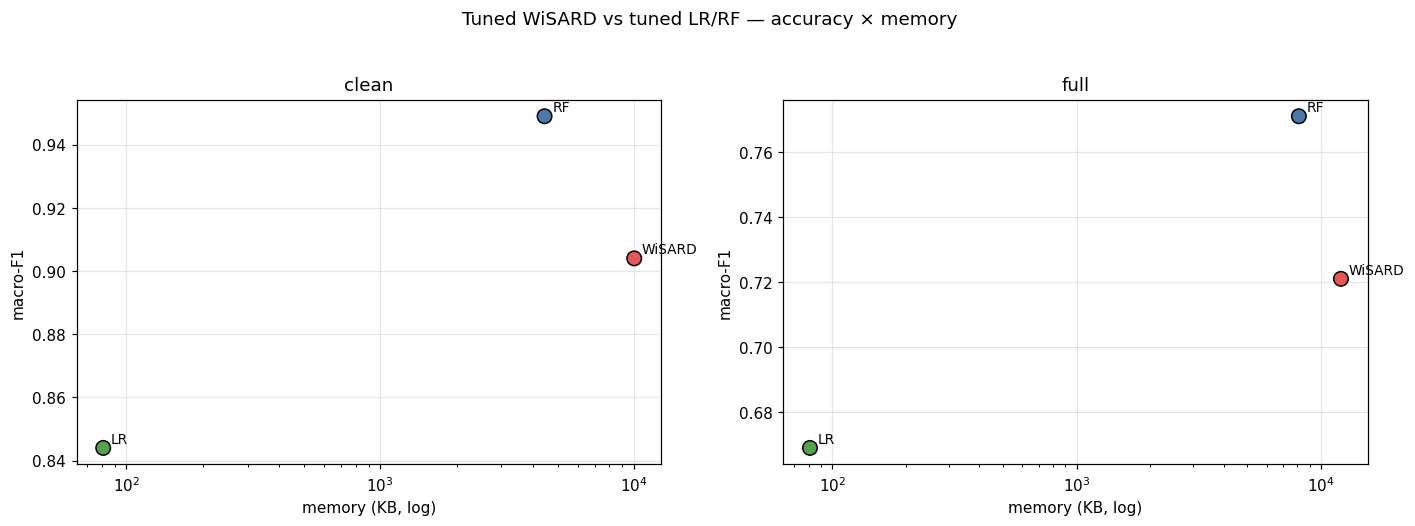

In [6]:
# Pareto: memory vs F1
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for ax, preset in zip(axes, ['clean', 'full']):
    sub = bench_df[bench_df.preset == preset]
    ax.scatter(sub.mem_kb, sub.f1, s=90, c=['#E45756', '#4C78A8', '#54A24B'], edgecolor='k', zorder=3)
    for _, r in sub.iterrows():
        ax.annotate(r['model'], (r.mem_kb, r.f1), fontsize=9, xytext=(5, 3), textcoords='offset points')
    ax.set_xscale('log'); ax.set_xlabel('memory (KB, log)'); ax.set_ylabel('macro-F1')
    ax.set_title(preset); ax.grid(alpha=0.3)
plt.suptitle('Tuned WiSARD vs tuned LR/RF — accuracy × memory', y=1.03); plt.tight_layout(); plt.show()

## Data-efficiency
How each tuned model scales with training set size (clean).

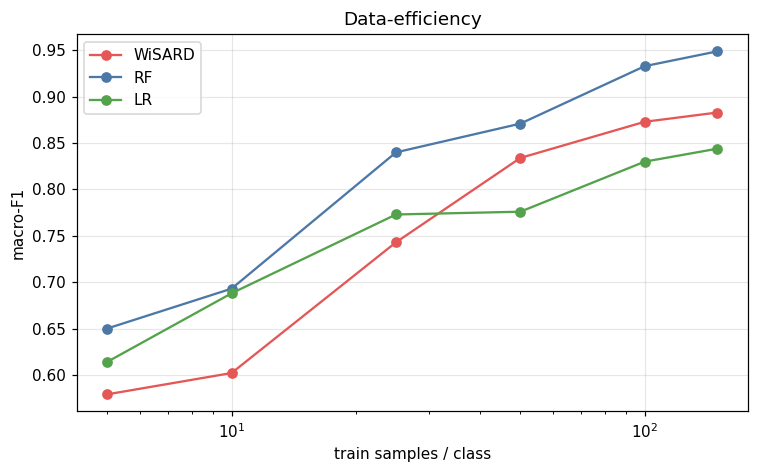

,WiSARD,RF,LR
n,,,
5,0.579,0.650,0.614
10,0.602,0.693,0.688
25,0.743,0.840,0.773
50,0.834,0.871,0.776
100,0.873,0.933,0.830
150,0.883,0.949,0.844


In [7]:
NS = [5, 10, 25, 50, 100, 150]
Xte, yte = data('clean', 60, 2)
curve = []
for n in NS:
    Xtr, ytr = data('clean', n, 1)
    row = {'n': n}
    for name, mdl in [('WiSARD', fit_wisard(Xtr, best)), ('RF', bench.SklearnModel('RF', make_rf())), ('LR', bench.SklearnModel('LR', make_lr()))]:
        row[name] = bench.evaluate(mdl, Xtr, ytr, Xte, yte, canon=CANON)['f1']
    curve.append(row)
cdf = pd.DataFrame(curve).set_index('n')
plt.figure(figsize=(7, 4.4))
for c, col in zip(cdf.columns, ['#E45756', '#4C78A8', '#54A24B']):
    plt.plot(cdf.index, cdf[c], '-o', label=c, color=col)
plt.xscale('log'); plt.xlabel('train samples / class'); plt.ylabel('macro-F1')
plt.title('Data-efficiency'); plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
cdf

## Error analysis — what went right, what went wrong
Beyond the scoreboard: *where* do the models fail? We rebuild a full-preset test set and
inspect confusions and example patches.

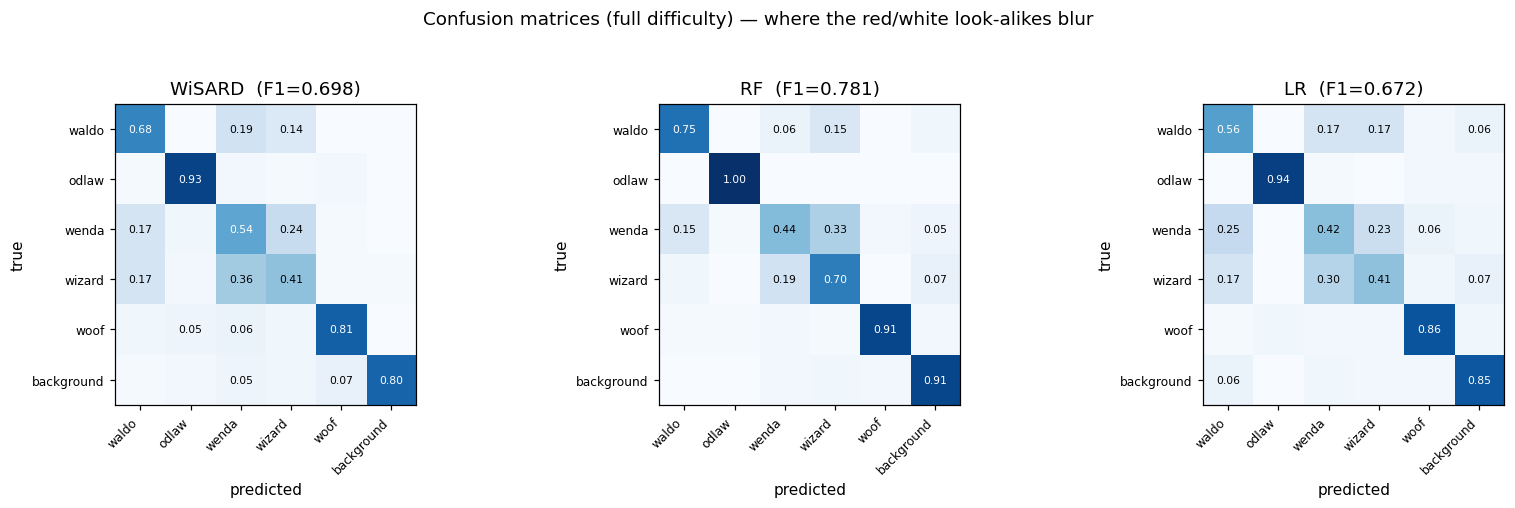

In [8]:
Xtr, ytr = data('full', 200, 1); Xte, yte = data('full', 80, 2)
preds = {}
for name, mk in [('WiSARD', lambda: fit_wisard(Xtr, best)), ('RF', lambda: bench.SklearnModel('RF', make_rf())), ('LR', lambda: bench.SklearnModel('LR', make_lr()))]:
    m = mk(); m.fit(Xtr, ytr); preds[name] = m.predict(Xte)
fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))
for a, name in zip(ax, preds):
    cm = confusion_matrix(yte, preds[name], labels=range(len(C.CLASSES)))
    cmn = cm / cm.sum(1, keepdims=True).clip(min=1)
    im = a.imshow(cmn, cmap='Blues', vmin=0, vmax=1)
    a.set_xticks(range(len(C.CLASSES))); a.set_xticklabels(C.CLASSES, rotation=45, ha='right', fontsize=8)
    a.set_yticks(range(len(C.CLASSES))); a.set_yticklabels(C.CLASSES, fontsize=8)
    a.set_title(f'{name}  (F1={f1_score(yte, preds[name], average="macro"):.3f})')
    a.set_xlabel('predicted'); a.set_ylabel('true')
    for i in range(len(C.CLASSES)):
        for j in range(len(C.CLASSES)):
            if cmn[i, j] > 0.04:
                a.text(j, i, f'{cmn[i,j]:.2f}', ha='center', va='center', fontsize=7,
                       color='white' if cmn[i, j] > 0.5 else 'black')
plt.suptitle('Confusion matrices (full difficulty) — where the red/white look-alikes blur', y=1.04)
plt.tight_layout(); plt.show()

Look at the off-diagonal mass: the systematic confusions are among the **red/white
striped** classes (`waldo` ↔ `wenda` ↔ `woof`) — exactly the look-alikes the books rely
on — while `odlaw` (yellow) and `background` are rarely confused. The models fail where
the *human* puzzle is hard.

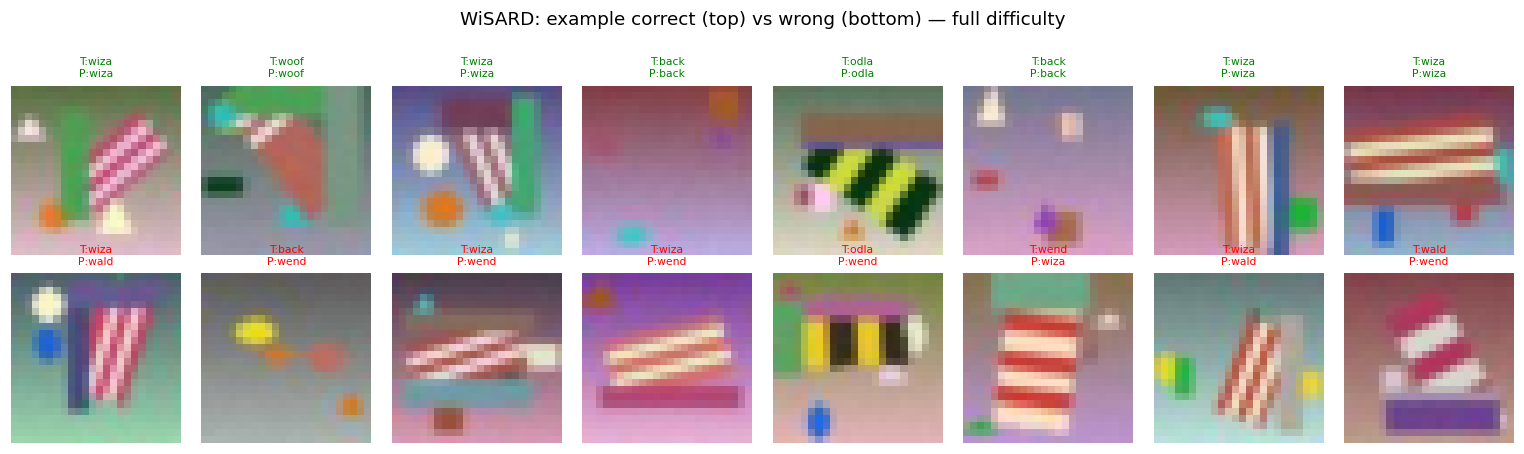

In [9]:
# Right/wrong gallery for one model (WiSARD)
name = 'WiSARD'; pr = preds[name]
correct = np.where(pr == yte)[0]; wrong = np.where(pr != yte)[0]
rng = np.random.default_rng(0)
def gallery(idx, title, axrow):
    pick = rng.choice(idx, size=min(8, len(idx)), replace=False)
    for a, i in zip(axrow, pick):
        a.imshow(Xte[i]); a.axis('off')
        a.set_title(f'T:{C.CLASSES[yte[i]][:4]}\nP:{C.CLASSES[pr[i]][:4]}', fontsize=7,
                    color='green' if pr[i] == yte[i] else 'red')
    axrow[0].set_ylabel(title)
fig, ax = plt.subplots(2, 8, figsize=(14, 4))
gallery(correct, 'correct', ax[0]); gallery(wrong, 'wrong', ax[1])
plt.suptitle(f'{name}: example correct (top) vs wrong (bottom) — full difficulty', y=1.02)
plt.tight_layout(); plt.show()

## How each model represents the problem
Three very different inductive biases on the *same* task — visualised in pixel space.

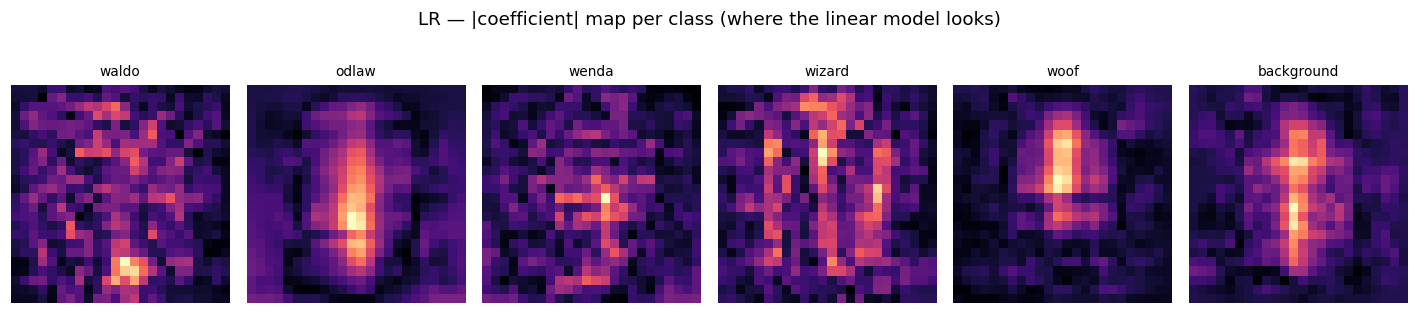

In [10]:
Xtr, ytr = data('clean', 200, 1)
# LR: per-class coefficient maps (which pixels push toward each class)
lr = make_lr().fit(feats(Xtr), ytr)
coef = lr.coef_.reshape(len(C.CLASSES), CANON, CANON, 3)
fig, ax = plt.subplots(1, len(C.CLASSES), figsize=(13, 2.6))
for k, (axk, cls) in enumerate(zip(ax, C.CLASSES)):
    w = np.abs(coef[k]).sum(-1); axk.imshow(w, cmap='magma'); axk.set_title(cls, fontsize=9); axk.axis('off')
plt.suptitle('LR — |coefficient| map per class (where the linear model looks)', y=1.08); plt.tight_layout(); plt.show()

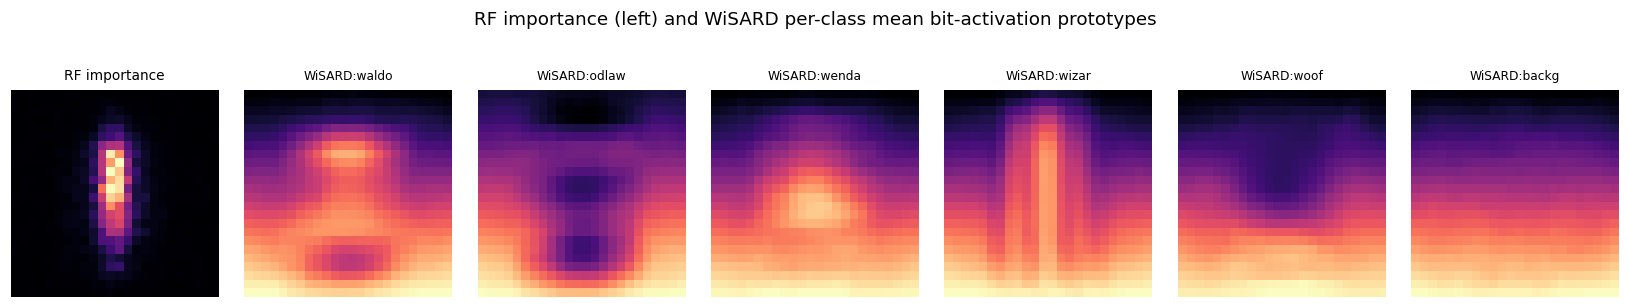

In [11]:
# RF: feature-importance map (summed over channels)
rf = make_rf().fit(feats(Xtr), ytr)
imp = rf.feature_importances_.reshape(CANON, CANON, 3).sum(-1)
# WiSARD: per-class 'mental image' — mean thermometer activation per class, collapsed to a saliency map
th = bench.fit_thermometer(Xtr, best['kind'], best['size'])
B = bench.thermometer_encode(Xtr, th).reshape(len(Xtr), CANON, CANON, 3, best['size'])
fig, ax = plt.subplots(1, 7, figsize=(15, 2.5))
ax[0].imshow(imp, cmap='magma'); ax[0].set_title('RF importance', fontsize=9); ax[0].axis('off')
for a, cls in enumerate(C.CLASSES):
    proto = B[ytr == a].mean(0).mean(-1).mean(-1)   # (canon,canon) mean on-rate
    ax[a + 1].imshow(proto, cmap='magma'); ax[a + 1].set_title(f'WiSARD:{cls[:5]}', fontsize=8); ax[a + 1].axis('off')
plt.suptitle('RF importance (left) and WiSARD per-class mean bit-activation prototypes', y=1.1)
plt.tight_layout(); plt.show()

The three biases are visibly different: **LR** spreads thin linear weight across the
striped region; **RF** concentrates importance on a few discriminative pixel rows; **WiSARD**
forms per-class *prototypes* — the mean bit-pattern it memorised — where the stripe layout
of each character is legible. None is "right"; they're three lenses on the same signal.

## Takeaways
- With **both sides tuned**, RF leads batch accuracy, LR is the lightest, and WiSARD is
  competitive but not dominant — the dataset does **not** secretly favour the weightless
  model. (Honest fairness, the whole point of this notebook.)
- The models fail **where the puzzle is genuinely hard** — among the red/white striped
  look-alikes — not on arbitrary noise.
- Each family represents the task differently; WiSARD's per-class prototypes are an
  interpretability bonus the encoding makes possible.
- Batch accuracy isn't WiSARD's edge. **03** turns to the regime where it structurally
  wins: class-incremental learning.